In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random
from model import UNet25D # Убедитесь, что импортируете актуальную версию

In [2]:
def test_wind_influence(data_dir, model_path, device='cuda', experiment_file = None):
    # 1. Загрузка модели
    # Укажите параметры n_channels (8) и wind_dim (3) как в вашей последней версии
    model = UNet25D(n_channels=8, n_classes=5, wind_dim=3).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    # 2. Выбор случайного примера
    files = glob.glob(os.path.join(data_dir, "*.npz"))
    if experiment_file:
        path = os.path.join(data_dir, experiment_file)
    else:
        path = random.choice(files)
    data = np.load(path)
    
    # x: (8, 128, 128), wind: (3,), y: (5, 128, 128)
    x_np = data['x']
    w_np = data['wind']
    
    # 3. Подготовка данных: Оригинал
    x_orig = torch.from_numpy(x_np).unsqueeze(0).to(device)
    w_orig = torch.from_numpy(w_np).unsqueeze(0).to(device)
    
    # 4. Подготовка данных: Инверсия ветра на 180 градусов
    # wind = [cos, sin, magnitude]
    # Чтобы повернуть на 180, нужно инвертировать cos и sin
    w_flip_np = w_np.copy()
    w_flip_np[0] = -w_np[0] # -cos
    w_flip_np[1] = -w_np[1] # -sin
    w_flip = torch.from_numpy(w_flip_np).unsqueeze(0).to(device)
    
    # ВНИМАНИЕ: Если ваша модель использует локальные каналы ветра в тензоре x (индексы 5, 6),
    # их тоже нужно обновить, чтобы тест был честным.
    x_flip_np = x_np.copy()
    x_flip_np[5] = w_flip_np[0] # Обновляем карту cos
    x_flip_np[6] = w_flip_np[1] # Обновляем карту sin
    x_flip = torch.from_numpy(x_flip_np).unsqueeze(0).to(device)

    # 5. Инференс
    with torch.no_grad():
        pred_orig_log = model(x_orig, w_orig)
        pred_flip_log = model(x_flip, w_flip)
        
    # Перевод в реальные значения
    pred_orig = torch.expm1(pred_orig_log).squeeze().cpu().numpy()
    pred_flip = torch.expm1(pred_flip_log).squeeze().cpu().numpy()

    # 6. Визуализация (Слой Z1 - Земля)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Карта зданий и источников
    axes[0].imshow(x_np[0], cmap='bone', origin='lower')
    # Рисуем стрелку оригинального ветра
    axes[0].arrow(64, 64, w_np[0]*20, w_np[1]*20, head_width=5, color='red', label='Orig Wind')
    # Рисуем стрелку инвертированного ветра
    axes[0].arrow(64, 64, w_flip_np[0]*20, w_flip_np[1]*20, head_width=5, color='cyan', label='Flip Wind')
    axes[0].set_title("Geometry & Wind Vectors")
    axes[0].legend()

    # Предсказание: Оригинальный ветер
    im1 = axes[1].imshow(pred_orig[0], cmap='turbo', origin='lower')
    axes[1].set_title(f"Pred: Original Wind\n(cos={w_np[0]:.2f}, sin={w_np[1]:.2f})")
    plt.colorbar(im1, ax=axes[1])

    # Предсказание: Инвертированный ветер
    im2 = axes[2].imshow(pred_flip[0], cmap='turbo', origin='lower')
    axes[2].set_title(f"Pred: Flipped 180°\n(cos={w_flip_np[0]:.2f}, sin={w_flip_np[1]:.2f})")
    plt.colorbar(im2, ax=axes[2])

    plt.suptitle(f"Wind Sensitivity Test: {os.path.basename(path)}")
    plt.tight_layout()
    plt.savefig("wind_test_result.png")
    plt.show()
    
    # Сохраним результат

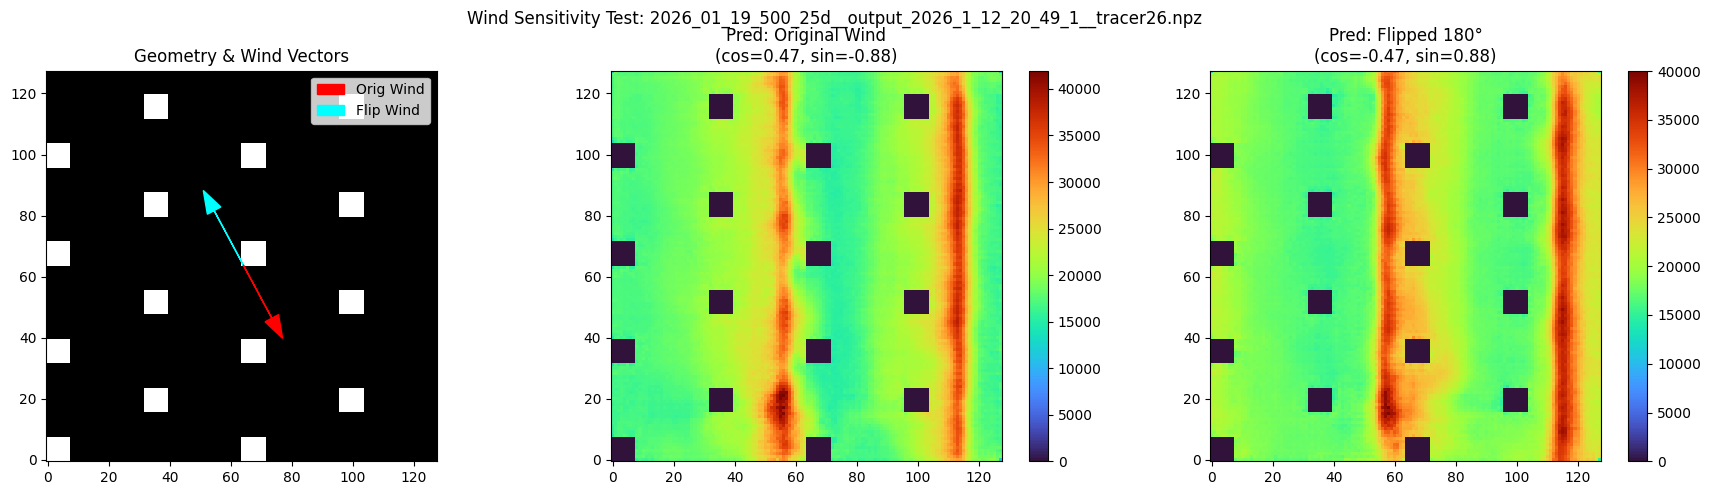

In [4]:
LATEST_MODEL = "./outputs/output_20260209_200327/unet_25d_v1_best.pth"
DATA_DIR = "/app/urban-layer-datasets/2026_01_19_500_25d_data_2/"
EXPERIMENT_FILE = "2026_01_19_500_25d__output_2026_1_12_20_49_1__tracer26.npz"
test_wind_influence(DATA_DIR, LATEST_MODEL, experiment_file=EXPERIMENT_FILE)